In [1]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos

Metodo de Cauchy / Metodo del punto medio para EDS del tipo $\frac{dy(t)}{dt} = f(t,y(t))$. Necesitamos conocer $f(t,y(t))$, $t_0$, $t_1$, $y_0 = y(t_0)$ y el tamaño del paso $h$.

La idea básica es hacer $y_{k+1} = y_{k} + \int_{t_k}^{t_{k+1}} f(s,y(s)) ds = y_k + h\,f(t_k + \frac{h}{2}, y_{k+1/2})$, con $y_{k+1/2} = y_k + \frac{h}{2}f(t_k,y_k)$. 

In [3]:
def yt(func,t0,t1,y0,h):
    # func = f(t,y(t))
    # t0 = valor incial
    # y0 = y(t0) limite inferior de t
    # y1 = limite superior de t
    # h = tamaño del paso

    N = int((t1-t0) / h) # Numero de subdivisiones

    y = np.zeros(N+1) #Pongo N+1 ya que luego en el bucle for llegamos hasta k+1 y si no se sale de rango
    t = np.zeros(N+1)

    y[0] = y0 
    t[0] = t0 

    for k in range (0,N,1):
        y[k+1] = y[k] + h * func(t[k]+h/2,y[k]+(h/2)*func(t[k],y[k]))
        t[k+1] = t[0] + (k+1) * h  # Efectivamente para k = N-1 recuperamos t1 = t0 + h*N

    return t,y

Una vez tenemos la función de Cauchy, ahora podemos aplicarla a un ejercicio real. Este ejemplo tiene los siguientes datos:

$\frac{dy}{dt} = y - t^2 +1$ con $y(0) = 0$

$t_0 = 0$, $t_1 = 2$ y $h = 0.1$



In [4]:
def f(t,y): # dy/dt = f(t,y)
    valor = y - t**2 + 1
    return valor

t0=0
t1=2
y0=0.5 # y(0)=0.5
h = 0.1

t,y = yt(f,t0,t1,y0,h) # Solucion numerica y(t)

La solución exacta de $y(t)$ es $y(t) = (t+1)^2 - 0.5\,e^{t}$. 

In [5]:
def sol_exac_y(t): # y(t) exacto (solucion simbolica)
    valor = (t+1)**2 - 0.5*(np.e**(t))
    return valor

La comprobación gráfica es:

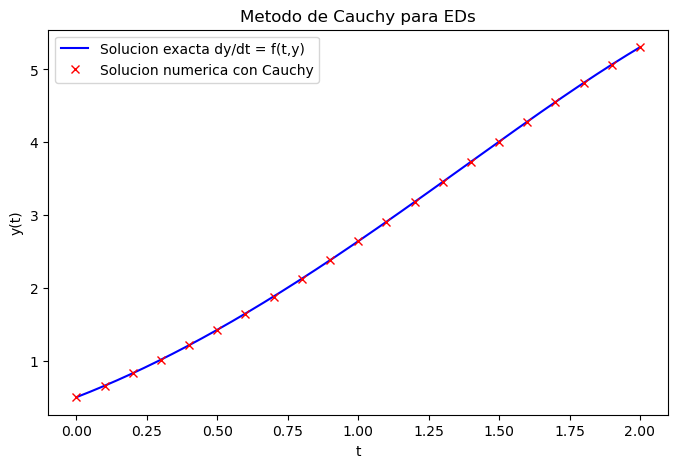

In [6]:
t_vals = np.linspace(t0, t1, 500) 
y_vals = sol_exac_y(t_vals)

plt.figure(figsize=(8, 5))
plt.plot(t_vals, y_vals, label='Solucion exacta dy/dt = f(t,y)', color='blue')
plt.plot(t, y, 'x',label='Solucion numerica con Cauchy', color='red')
plt.title('Metodo de Cauchy para EDs')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(False)
plt.show()